# Chapter 14 - Orbit Correction

While operating an accelerator, the beam orbit is measured at selected locations with beam position monitors (BPMs). The design orbit is often chosen so the ideal BPM readings are zero, but a real machine may instead use a measured reference orbit, often called a golden orbit. Orbit correction changes the beam trajectory so the BPM readings approach the desired values.

In this SciBmad notebook, a BPM is represented as a zero-length `Marker`: it gives us a named location where the orbit can be read. A corrector is represented as a `Kicker`: it can apply a small transverse kick and therefore changes the downstream orbit.


In [6]:
using SciBmad
using CairoMakie
using LinearAlgebra
using Statistics
using Printf


## 14.1 Adding Corrector Coils and BPMs

We start from the original examplering lattice and add two kinds of elements:

- horizontal correctors near focusing quadrupoles;
- vertical correctors near defocusing quadrupoles;
- BPM markers after dipoles, where the orbit will be sampled.

To make room for a corrector inside the `D1` drift, split the original `0.609 m` drift into three pieces:

| Piece | Role | Length |
|---|---|---:|
| `D1C1` | short drift before or after the corrector | `0.064 m` |
| `CH` or `CV` | horizontal or vertical corrector | `0.2 m` |
| `D1C2` | remaining drift | `0.345 m` |

The total length is unchanged: `0.064 + 0.2 + 0.345 = 0.609 m`.


In [7]:
const CH14_SPECIES = Species("electron")
const CH14_E_REF = 1.7846262612447e10

const D1_TOTAL = 0.609
const D1C1_L = 0.064
const CORRECTOR_L = 0.2
const D1C2_L = D1_TOTAL - D1C1_L - CORRECTOR_L

@assert isapprox(D1C1_L + CORRECTOR_L + D1C2_L, D1_TOTAL)

function d1c1(name="D1C1")
    return Drift(name=name, L=D1C1_L)
end

function d1c2(name="D1C2")
    return Drift(name=name, L=D1C2_L)
end

function horizontal_corrector(name)
    return Kicker(name=name, L=CORRECTOR_L)
end

function vertical_corrector(name)
    return Kicker(name=name, L=CORRECTOR_L)
end

function bpm(name)
    return Marker(name=name)
end


bpm (generic function with 1 method)

The placement follows the FODO-cell optics. In a forward cell, the horizontal corrector is placed just after the focusing quadrupole, and the vertical corrector is placed just after the defocusing quadrupole. In a reverse cell, the order is mirrored, so the corrector appears before the corresponding quadrupole.

The example below writes this directly as SciBmad element lists for one forward and one reverse FODO cell.


In [8]:
function forward_fodo_with_correctors(; suffix="")
    return [
        Quadrupole(name="QF" * suffix, L=0.5, Kn1=0.312808574467162),
        d1c1("D1C1_QF" * suffix),
        horizontal_corrector("CH" * suffix),
        d1c2("D1C2_QF" * suffix),
        SBend(name="B1" * suffix, L=6.86016190935103, g_ref=3.46929776000413e-3, Kn0=3.46929776000413e-3),
        bpm("BPM_B1" * suffix),
        Drift(name="D2" * suffix, L=1.241),
        Quadrupole(name="QD" * suffix, L=0.5, Kn1=-0.312643401293818),
        d1c1("D1C1_QD" * suffix),
        vertical_corrector("CV" * suffix),
        d1c2("D1C2_QD" * suffix),
        SBend(name="B2" * suffix, L=6.86016190935103, g_ref=3.46929776000413e-3, Kn0=3.46929776000413e-3),
        bpm("BPM_B2" * suffix),
        Drift(name="D2_END" * suffix, L=1.241),
    ]
end

function reverse_fodo_with_correctors(; suffix="")
    return [
        Quadrupole(name="QF" * suffix, L=0.5, Kn1=0.312808574467162),
        Drift(name="D2" * suffix, L=1.241),
        SBend(name="B1" * suffix, L=6.86016190935103, g_ref=3.46929776000413e-3, Kn0=3.46929776000413e-3),
        bpm("BPM_B1" * suffix),
        d1c2("D1C2_QD" * suffix),
        vertical_corrector("CV" * suffix),
        d1c1("D1C1_QD" * suffix),
        Quadrupole(name="QD" * suffix, L=0.5, Kn1=-0.312643401293818),
        Drift(name="D2_MID" * suffix, L=1.241),
        SBend(name="B2" * suffix, L=6.86016190935103, g_ref=3.46929776000413e-3, Kn0=3.46929776000413e-3),
        bpm("BPM_B2" * suffix),
        d1c2("D1C2_QF" * suffix),
        horizontal_corrector("CH" * suffix),
        d1c1("D1C1_QF" * suffix),
    ]
end

forward_cell = Beamline(
    forward_fodo_with_correctors();
    species_ref=CH14_SPECIES,
    E_ref=CH14_E_REF,
)

reverse_cell = Beamline(
    reverse_fodo_with_correctors();
    species_ref=CH14_SPECIES,
    E_ref=CH14_E_REF,
)


Beamline:
 species_ref = electron
 E_ref = 1.7846262612447e10

  Index   Name      Kind         s [m]   
  1       QF        Quadrupole   0
  2       D2        Drift        0.5
  3       B1        SBend        1.741
  4       BPM_B1    Marker       8.60116
  5       D1C2_QD   Drift        8.60116
  6       CV        Kicker       8.94616
  7       D1C1_QD   Drift        9.14616
  8       QD        Quadrupole   9.21016
  9       D2_MID    Drift        9.71016
  10      B2        SBend        10.9512
  11      BPM_B2    Marker       17.8113
  12      D1C2_QF   Drift        17.8113
  13      CH        Kicker       18.1563
  14      D1C1_QF   Drift        18.3563


For a quick check, print the sequence of elements and the running longitudinal position. The BPM rows are the orbit readback locations; the `CH` and `CV` rows are the correctors that later orbit-correction routines can vary.


In [9]:
function element_kind(element)
    return last(split(string(typeof(element)), "."))
end

function element_length(element)
    return hasproperty(element, :L) ? element.L : 0.0
end

function show_lattice_structure(elements)
    @printf("%5s  %-14s  %-14s  %9s  %9s
", "idx", "name", "kind", "L [m]", "s [m]")
    s = 0.0
    for (idx, element) in enumerate(elements)
        L = element_length(element)
        s += L
        @printf("%5d  %-14s  %-14s  %9.3f  %9.3f
", idx, string(element.name), element_kind(element), L, s)
    end
end

show_lattice_structure(forward_cell.line)


  idx  name            kind                L [m]      s [m]
    1  QF              LineElement         0.500      0.500
    2  D1C1_QF         LineElement         0.064      0.564
    3  CH              LineElement         0.200      0.764
    4  D1C2_QF         LineElement         0.345      1.109
    5  B1              LineElement         6.860      7.969
    6  BPM_B1          LineElement         0.000      7.969
    7  D2              LineElement         1.241      9.210
    8  QD              LineElement         0.500      9.710
    9  D1C1_QD         LineElement         0.064      9.774
   10  CV              LineElement         0.200      9.974
   11  D1C2_QD         LineElement         0.345     10.319
   12  B2              LineElement         6.860     17.179
   13  BPM_B2          LineElement         0.000     17.179
   14  D2_END          LineElement         1.241     18.420


The useful separation is:

- `Marker` BPMs do not affect tracking. They are named places where we can sample the orbit.
- `Kicker` correctors are active beamline elements. Changing their kick strengths changes the downstream trajectory.
- The same insertion pattern can be repeated throughout the full ring: forward arcs, reverse arcs, dispersion suppressors, and straight sections.

This sets up the ingredients needed for orbit correction: measured orbit values at BPMs and adjustable kick strengths at correctors.


In [10]:
function bpm_names(elements)
    return [string(element.name) for element in elements if startswith(string(element.name), "BPM")]
end

function corrector_names(elements)
    return [string(element.name) for element in elements if startswith(string(element.name), "CH") || startswith(string(element.name), "CV")]
end

println("Forward-cell BPMs:       ", join(bpm_names(forward_cell.line), ", "))
println("Forward-cell correctors: ", join(corrector_names(forward_cell.line), ", "))


Forward-cell BPMs:       BPM_B1, BPM_B2
Forward-cell correctors: CH, CV


## 14.2 Radiation-Induced Sawtooth Orbit Correction

Synchrotron radiation causes electrons to lose energy as they travel through the ring. The RF cavities restore that energy, so the particle energy varies around the ring instead of staying perfectly constant. Since the horizontal closed orbit depends on the local momentum error, this energy variation creates a sawtooth-like horizontal orbit.

In this section we first make a simple BPM-level sawtooth orbit so the effect is visible in SciBmad. Then we discuss tapering. Finally, we correct the horizontal BPM readings by varying horizontal corrector strengths.


### 14.2.1 Displaying a Sawtooth Orbit

The full radiation model is not needed to see the orbit-correction workflow. We build a demo ring from repeated FODO cells, read the positions of BPMs and horizontal correctors, and assign a sawtooth-shaped horizontal BPM reading. The small sinusoidal ripple is included only to make the example look more like a realistic orbit readback instead of a perfectly straight ramp.


In [11]:
function build_chapter14_demo_ring(; n_cells=18)
    elements = Any[]
    for cell in 1:n_cells
        append!(elements, forward_fodo_with_correctors(; suffix=@sprintf("_%02d", cell)))
    end
    return Beamline(elements; species_ref=CH14_SPECIES, E_ref=CH14_E_REF)
end

function element_positions(beamline)
    rows = NamedTuple[]
    s = 0.0
    for (idx, element) in enumerate(beamline.line)
        L = element_length(element)
        s += L
        push!(rows, (; index=idx, name=string(element.name), kind=element_kind(element), s=s, L=L))
    end
    return rows
end

function selected_positions(rows, prefix)
    selected = filter(row -> startswith(row.name, prefix), rows)
    return [row.name for row in selected], [row.s for row in selected]
end

function sawtooth_orbit(s; circumference, amplitude=4.0e-4, n_rf=6, ripple=5.0e-5)
    phase = mod(n_rf * s / circumference, 1.0)
    ramp = amplitude * (2phase - 1)
    betatron_ripple = ripple * sin(2pi * 7.3 * s / circumference)
    return ramp + betatron_ripple
end

demo_ring = build_chapter14_demo_ring()
rows = element_positions(demo_ring)
circumference = rows[end].s

bpm_names_14, bpm_s = selected_positions(rows, "BPM")
ch_names_14, ch_s = selected_positions(rows, "CH")

x_sawtooth = [sawtooth_orbit(s; circumference=circumference) for s in bpm_s]

@printf("Demo ring circumference: %.3f m\n", circumference)
@printf("BPM count: %d, horizontal corrector count: %d\n", length(bpm_s), length(ch_s))
@printf("Initial horizontal BPM rms: %.3f mm\n", 1e3 * sqrt(mean(abs2, x_sawtooth)))


Demo ring circumference: 331.566 m
BPM count: 36, horizontal corrector count: 18
Initial horizontal BPM rms: 0.235 mm


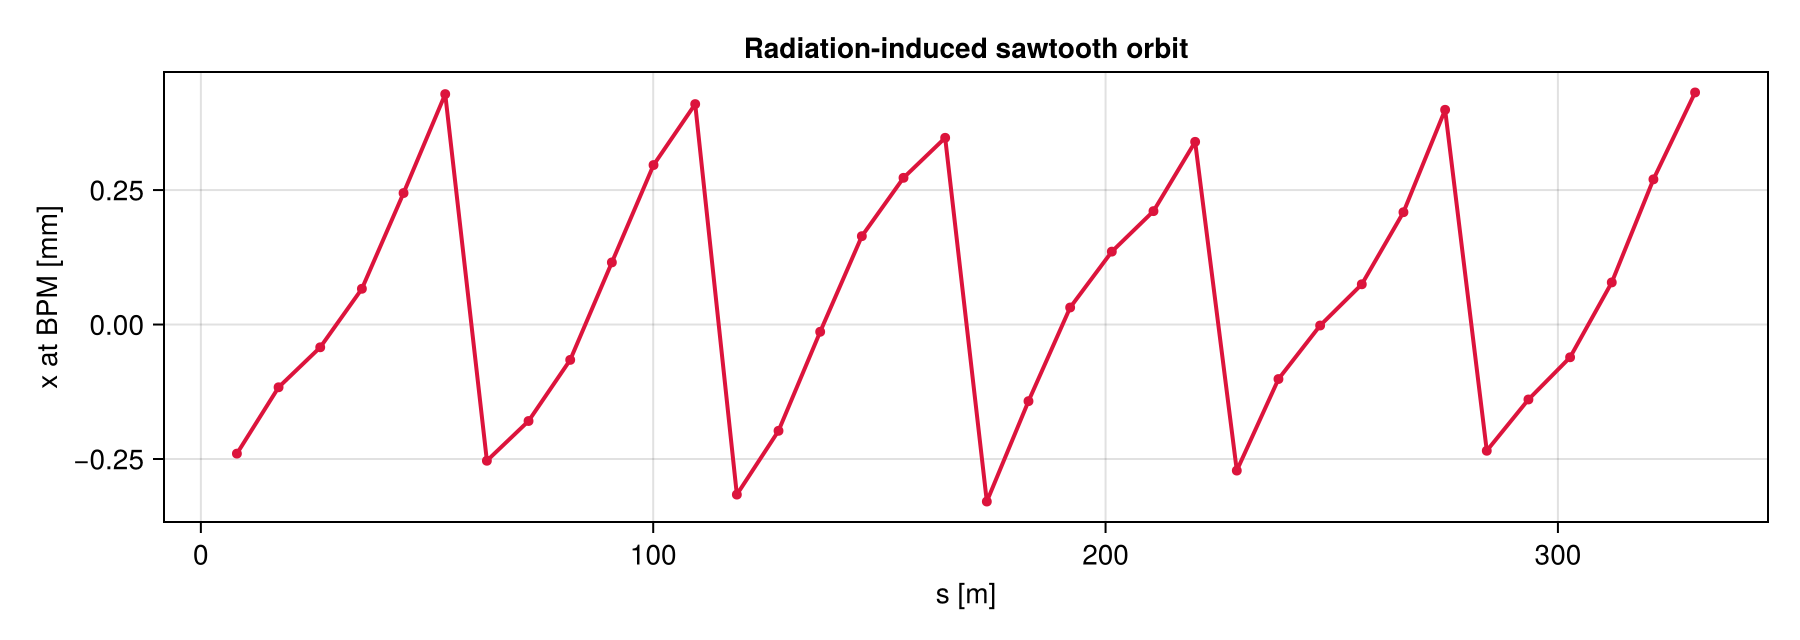

In [12]:
fig = Figure(size=(900, 320))
ax = Axis(fig[1, 1], xlabel="s [m]", ylabel="x at BPM [mm]", title="Radiation-induced sawtooth orbit")
lines!(ax, bpm_s, 1e3 .* x_sawtooth; color=:crimson, linewidth=2)
scatter!(ax, bpm_s, 1e3 .* x_sawtooth; color=:crimson, markersize=7)
fig


### 14.2.2 Tapering

Tapering corrects the sawtooth effect by changing magnet strengths according to the local energy around the ring. The idea is different from orbit correction with correctors: tapering changes the lattice magnets themselves so their effective focusing and bending strengths match the local beam energy.

A SciBmad implementation would need a careful element-by-element model of the local energy profile and the corresponding rescaling of magnet strengths. That is still something to study before we put it into this notebook. For now, we continue with the alternative method: correct the measured horizontal orbit using horizontal correctors.


### 14.2.3 Correcting the Sawtooth Orbit with Horizontal Correctors

Now use the BPM readings as the data to correct and the horizontal corrector strengths as variables. Since the sawtooth is horizontal, we only use `CH` correctors and only fit the horizontal BPM readings.

The code below builds a simple orbit-response matrix. Each column says how the horizontal BPM orbit changes when one horizontal corrector receives a unit kick. The optimizer solves a regularized least-squares problem:

$$
R k \approx -x_{BPM}
$$

where `R` is the response matrix, `k` is the vector of corrector kicks, and `x_BPM` is the sawtooth orbit measured at BPMs.


In [13]:
function ring_phase(s; circumference, tune)
    return 2pi * tune * s / circumference
end

function wrapped_phase_difference(a, b)
    return abs(mod(a - b + pi, 2pi) - pi)
end

function horizontal_response_matrix(bpm_s, ch_s; circumference, tune=6.23, beta_bpm=18.0, beta_ch=18.0)
    # Closed-orbit response for a thin horizontal kick.
    # Units: meters of BPM displacement per radian of corrector kick.
    response = zeros(length(bpm_s), length(ch_s))
    denom = 2sin(pi * tune)

    for i in eachindex(bpm_s)
        phi_i = ring_phase(bpm_s[i]; circumference=circumference, tune=tune)
        for j in eachindex(ch_s)
            phi_j = ring_phase(ch_s[j]; circumference=circumference, tune=tune)
            dphi = wrapped_phase_difference(phi_i, phi_j)
            response[i, j] = sqrt(beta_bpm * beta_ch) / denom * cos(pi * tune - dphi)
        end
    end

    return response
end

function optimize_horizontal_correctors(bpm_s, ch_s, x_bpm; circumference, tune=6.23, regularization=1e-6)
    R = horizontal_response_matrix(bpm_s, ch_s; circumference=circumference, tune=tune)

    # The regularization term keeps the solution from using unnecessarily large kicks.
    A = [R; sqrt(regularization) * I(size(R, 2))]
    b = [-x_bpm; zeros(size(R, 2))]

    kicks = A \ b
    corrected_x = x_bpm + R * kicks

    return (; kicks, corrected_x, response=R)
end

solution = optimize_horizontal_correctors(bpm_s, ch_s, x_sawtooth; circumference=circumference)
x_corrected = solution.corrected_x

@printf("Corrected horizontal BPM rms: %.4f mm\n", 1e3 * sqrt(mean(abs2, x_corrected)))
@printf("Largest horizontal kick: %.3e rad\n", maximum(abs, solution.kicks))


Corrected horizontal BPM rms: 0.1347 mm
Largest horizontal kick: 5.568e-03 rad


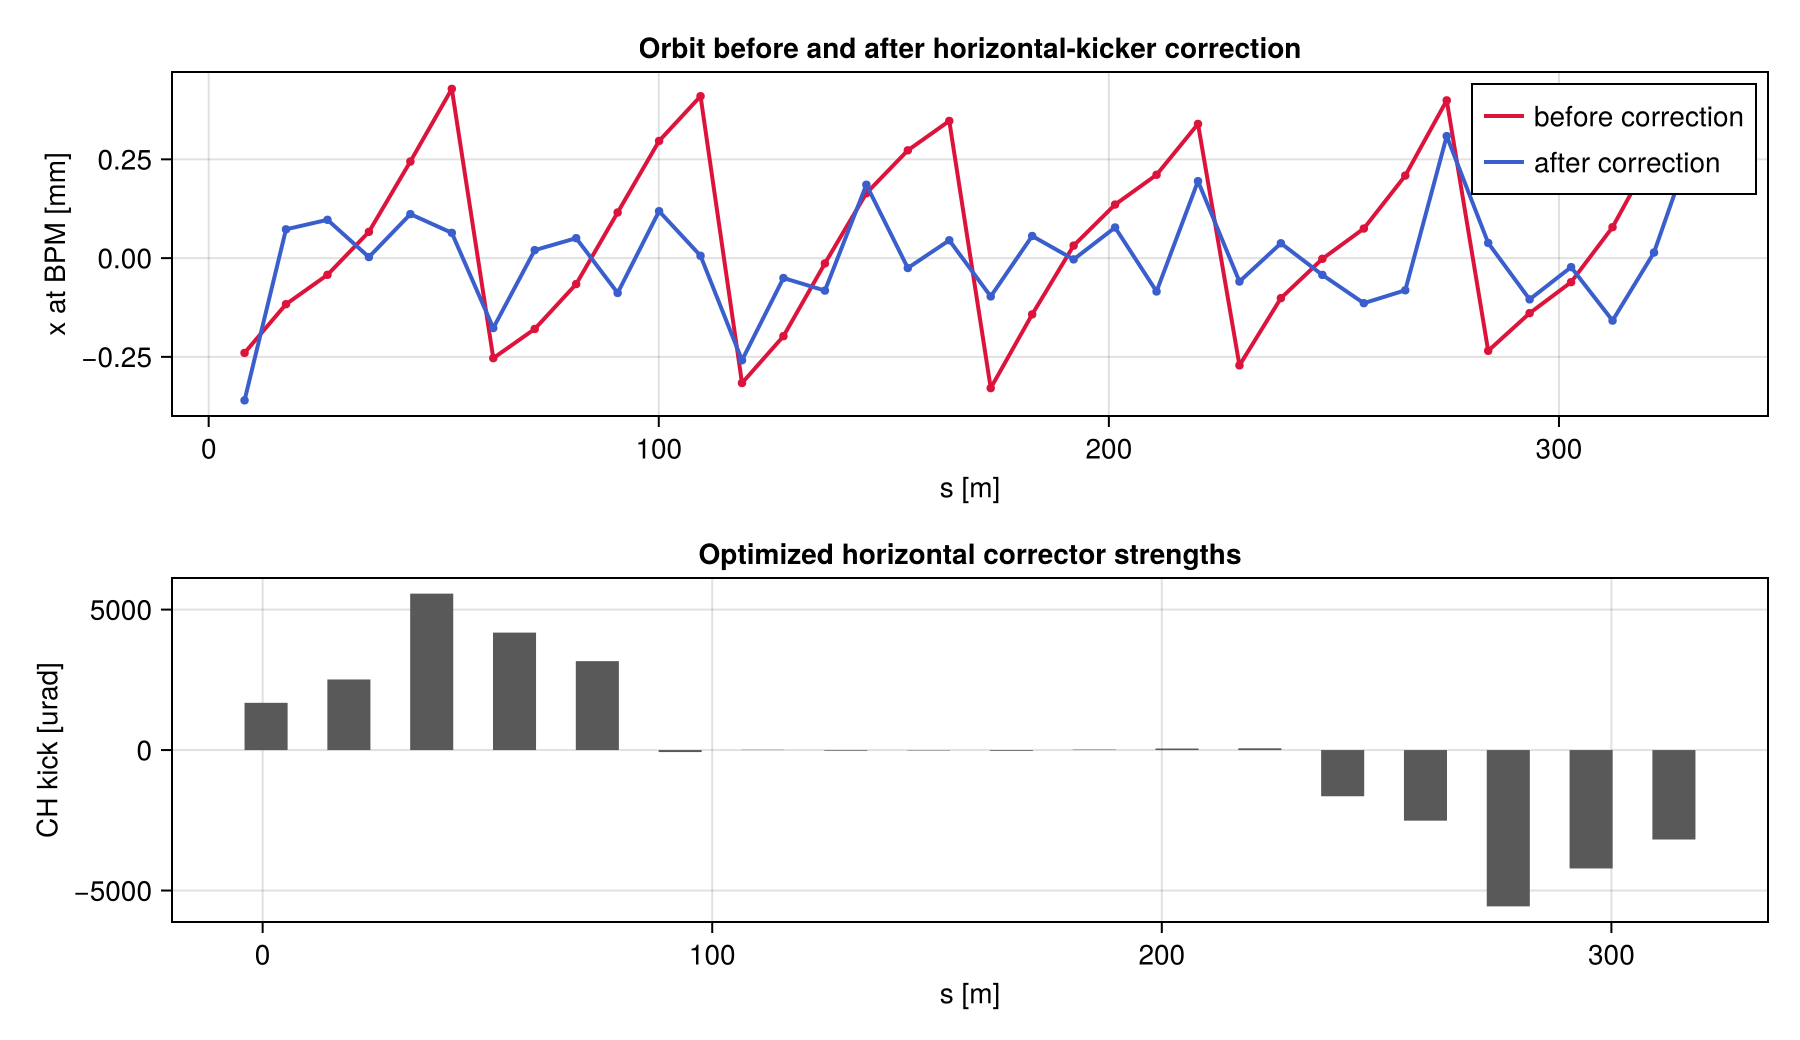

In [14]:
fig = Figure(size=(900, 520))

ax1 = Axis(fig[1, 1], xlabel="s [m]", ylabel="x at BPM [mm]", title="Orbit before and after horizontal-kicker correction")
lines!(ax1, bpm_s, 1e3 .* x_sawtooth; color=:crimson, linewidth=2, label="before correction")
scatter!(ax1, bpm_s, 1e3 .* x_sawtooth; color=:crimson, markersize=6)
lines!(ax1, bpm_s, 1e3 .* x_corrected; color=:royalblue3, linewidth=2, label="after correction")
scatter!(ax1, bpm_s, 1e3 .* x_corrected; color=:royalblue3, markersize=6)
axislegend(ax1; position=:rt)

ax2 = Axis(fig[2, 1], xlabel="s [m]", ylabel="CH kick [urad]", title="Optimized horizontal corrector strengths")
barplot!(ax2, ch_s, 1e6 .* solution.kicks; color=:gray35, width=0.65 * median(diff(ch_s)))

fig


In [15]:
println("First few optimized horizontal correctors:")
for idx in 1:min(8, length(ch_names_14))
    @printf("  %-10s  %+10.4f urad\n", ch_names_14[idx], 1e6 * solution.kicks[idx])
end


First few optimized horizontal correctors:
  CH_01       +1681.8165 urad
  CH_02       +2512.0005 urad
  CH_03       +5567.6047 urad
  CH_04       +4180.7454 urad
  CH_05       +3164.7181 urad
  CH_06         -71.6314 urad
  CH_07          +9.4450 urad
  CH_08         -23.8369 urad
